In [185]:
import os
#import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [186]:
# Read in the results and combine them
df_par = pd.read_csv("results_parallel.csv")
df_ser = pd.read_csv("results_serial.csv")
df_ser = df_ser.loc[df_ser["nthreads"] == 1]
df = pd.concat([df_par, df_ser], axis=0)

In [187]:
# Function to create a table with number of cores and size of the input matrix
def create_av_table(df, precision=2):
    nthreads_list = sorted(df["nthreads"].unique())
    sizes_list = sorted(df["size"].unique())

    ncpu_size = []

    for nthreads in nthreads_list:
        rows = []
        for size in sizes_list:
            #print(f"{size = }, {nthreads = }")
            rows.append(df.loc[(df["size"] == size) & (df["nthreads"] == nthreads)]["time"].mean())
        ncpu_size.append(rows)

    res = pd.DataFrame(ncpu_size, columns=sizes_list, index=nthreads_list).round(precision)
    return res

In [188]:
def get_av_times(df):
    return df.groupby(["size", "nthreads"])["time"].mean().to_frame().reset_index()

In [189]:
def get_speedup_eff(df):
    nthreads_list = sorted(df["nthreads"].unique())
    colnames = sorted(df["size"].unique())

    index = nthreads_list[1:]

    df_avs = df.groupby(["size", "nthreads"])["time"].mean().to_frame().reset_index()

    res_speedup = []
    res_eff = []

    for nthreads in nthreads_list[1:]:
        rows_speedup = []
        rows_eff = []
        for size in colnames:
            # Do not calculate speedup for 8192 because it couldn't be run serially
            if size == 8192:
                rows_speedup.append(None)
                rows_eff.append(None)
                continue
                
            t_ser = df_avs.loc[(df_avs["nthreads"] == 1) & (df_avs["size"] == size)]["time"].values[0]
            t_par = df_avs.loc[(df_avs["nthreads"] == nthreads) & (df_avs["size"] == size)]["time"].values[0]
            #print(f"{size, nthreads}")
            #print(f"{t_par=}\n")

            speedup = t_ser/t_par
            eff = speedup/nthreads
            rows_speedup.append(speedup)
            rows_eff.append(eff)

        res_speedup.append(rows_speedup)
        res_eff.append(rows_eff)

    spu = pd.DataFrame(res_speedup, columns=colnames, index=index)
    eff = pd.DataFrame(res_eff, columns=colnames, index=index)
    
    return (spu, eff)

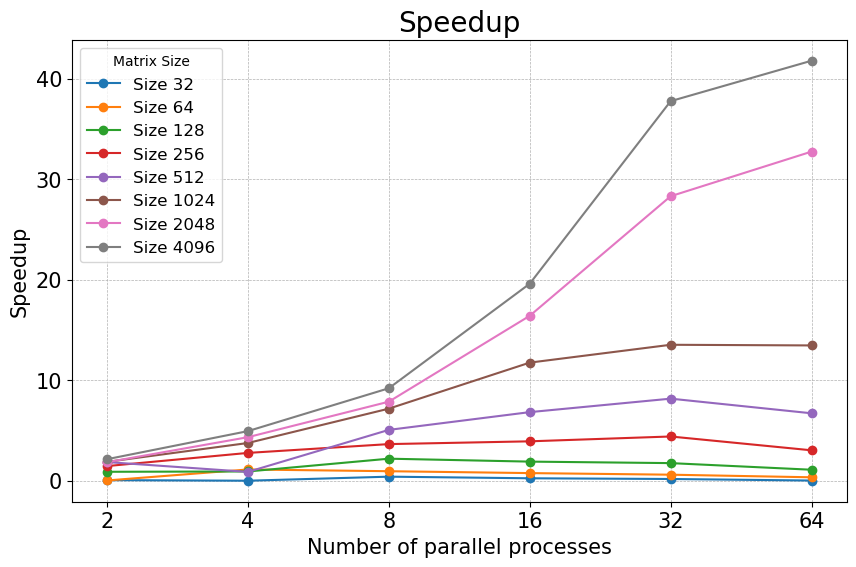

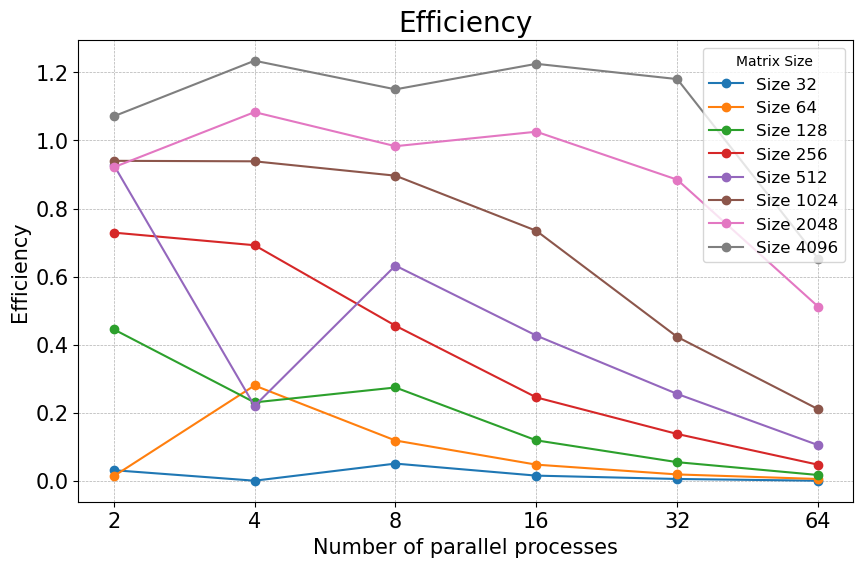

In [190]:
spu, eff = get_speedup_eff(df)
x_ticks = sorted(df["nthreads"].unique())[1:]

def plot_data(df, x_label, y_label, title):
    # Plot each column (matrix size) as a function of nthreads (index)
    plt.figure(figsize=(10, 6))

    for size in df.columns:
        if size == 8192:
            continue
        plt.plot(df.index, df[size], marker='o', label=f"Size {size}")

    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xscale("log", base=2)
    #plt.yscale("log")
    plt.xticks(x_ticks, labels=[str(x) for x in x_ticks], fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(title="Matrix Size", fontsize=12)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.title(title, fontsize=20)

    plt.show()

plot_data(spu, "Number of parallel processes", "Speedup", "Speedup")
plot_data(eff, "Number of parallel processes", "Efficiency", "Efficiency")


In [191]:
create_av_table(df)

,32,64,128,256,512,1024,2048,4096,8192
1,0.00,0.00,0.02,0.17,1.35,10.74,86.34,807.98,NaN
2,0.01,0.11,0.02,0.12,0.73,5.71,46.87,377.24,2990.39
4,0.32,0.00,0.02,0.06,1.53,2.86,19.92,163.64,2072.51
8,0.00,0.00,0.01,0.05,0.27,1.50,10.98,87.80,764.81
16,0.00,0.00,0.01,0.04,0.20,0.91,5.26,41.21,333.71
32,0.00,0.00,0.01,0.04,0.16,0.79,3.05,21.39,170.16
64,0.02,0.01,0.02,0.06,0.20,0.80,2.64,19.33,210.23
